In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import scienceplots, os
from scipy.interpolate import RegularGridInterpolator
plt.style.use(['science', 'bright', 'vpedre'])
from classy import Class
from pathlib import Path
os.chdir('../')
import python.vp_utils as utils

# Loading data

In [55]:
from collections import defaultdict

models = ['lcdm', 'frhs', 'ndgp']

base_path = Path('output')

data_m = defaultdict(dict)
data_zz = []
# Loop over models
for model in models:
    if model == 'lcdm': n_snap = 27
    else: n_snap = 25
    for i in range(n_snap):
        if model=='lcdm': data_zz.append(np.load(base_path / model / f"Pk_matter/{i:03d}.npy", allow_pickle=True).item()['z'])
        data_m[model][i] = np.load(base_path / model / f"Pk_matter/{i:03d}.npy", allow_pickle=True).item()

data_zz = np.array(data_zz)

# CLASS matter power spectrum

In [ ]:
idx = 4
Pk, kk, z = data_m['lcdm'][0]['Pk'], data_m['lcdm'][0]['k'], data_m['lcdm'][0]['z']

In [63]:
pars_planck = {
    'Omega_m': 0.31315,
    'h': 0.67370,
    # 'sigma8': 7.9347000e-01,
    'A_s': 2.0969200e-9,
    'output': 'mPk',
    'z_max_pk': data_zz.max(),
    'non_linear': 'halofit',
    # 'k_output_values': ','.join([str(k) for k in k_ref_m]),
}

pars_mg = {
    'output': 'mPk',
    # 'non_linear': 'halofit',
    'z_max_pk': data_zz.max(),
    'Omega_b':   0.049199,
    'Omega_cdm': 0.31315 - 0.049199, 
    'h':         0.6737,
    'n_s':       0.9652,
    'A_s':       2.0969200e-9,
}

lcdm = Class()

lcdm.set(pars_mg)
lcdm.compute()

# Define k values to evaluate the power spectrum at
# kk = np.geomspace(k_min, k_max, 100)  # k values in h/Mpc

# Initialize a dictionary to store results for each redshift
Pk_class = {}

# Compute power spectrum for all redshifts in z_array
for z in data_zz:
    Pk_class[z] = lcdm.get_pk_all(kk, z)

ValueError: A value (1.1216966312226337) in x_new is above the interpolation range's maximum value (1.1185917360243582).

# Plotting

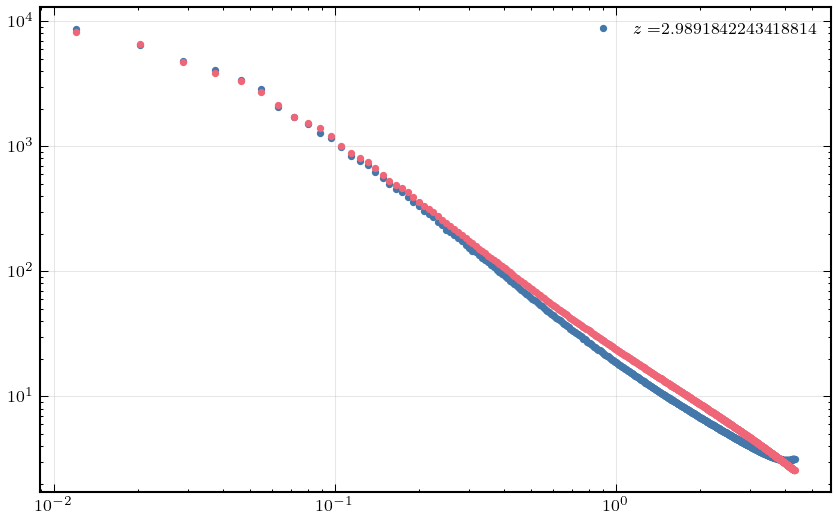

In [61]:
z = data_m['lcdm'][0]['z']

fig, ax = plt.subplots()

ax.loglog(kk, Pk, '.', label=rf'$z=${z}')
ax.loglog(kk, Pk_class[z], '.')
ax.legend()